# Задание 2


In [ ]:
#загружаем нужные библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest 

In [32]:
#загружаем данные
df = pd.read_csv('Проект_1_Задание_2.csv', sep=';')
df.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [33]:
#посмотрим общую информацию о данных
df.info

<bound method DataFrame.info of         user_id  revenue testgroup
0             1        0         b
1             2        0         a
2             3        0         a
3             4        0         b
4             5        0         b
...         ...      ...       ...
404765   404766        0         a
404766   404767        0         b
404767   404768      231         a
404768   404769        0         a
404769   404770        0         b

[404770 rows x 3 columns]>

# Расчет базовых метрик

Определим продуктовые метрики и расчитаем их для каждой группы. Определим следующие продуктовые метрики, необходимые для дальнейшего анализа:
1. Конверсия в платящего клиента (CR)
2. Средний чек на одного клиента из общего числа клиентов (ARPU)
3. Средний чек на одного клиента из числа платящих (ARPPU)

In [34]:
# Создаем агрегированную таблицу по группам
metrics = df.groupby('testgroup').agg(
    total_users=('user_id', 'count'),
    paying_users=('revenue', lambda x: (x > 0).sum()),
    total_revenue=('revenue', 'sum')
).reset_index()

# CR (Conversion Rate) выразим в процентах для наглядности
metrics['CR_%'] = (metrics['paying_users'] / metrics['total_users']) * 100

# ARPU (Average Revenue Per User)
metrics['ARPU'] = metrics['total_revenue'] / metrics['total_users']

# ARPPU (Average Revenue Per Paying User)
metrics['ARPPU'] = metrics['total_revenue'] / metrics['paying_users']

# 3. Красиво форматируем и выводим результат
# Округлим расчетные метрики до двух-трех знаков после запятой
metrics_styled = metrics.round({'CR_%': 3, 'ARPU': 2, 'ARPPU': 2})

print("Сводная таблица продуктовых метрик по группам:")
print(metrics_styled.to_string(index=False))

Сводная таблица продуктовых метрик по группам:
testgroup  total_users  paying_users  total_revenue  CR_%  ARPU   ARPPU
        a       202103          1928        5136189 0.954 25.41 2664.00
        b       202667          1805        5421603 0.891 26.75 3003.66


На основании полученных данных видим:
1. a - контрольная группа, b - тестовая группа
2. общая сумма платежей в тестовой группе выше, чем в контрольной, но конверсия в платящего клиента выше в контрольной группе
3. средний чек на одного игрока из общего числа и из числа платящих клиентов (ARPU и  ARPPU) выше в тестовой группе

Первичные полученные данные не позволяют сделать выводы, поэтому рассмотрим данные по платящим пользователям более детально.
Проведем визуальный анализ платящих клиентов, смотрим только на тех, кто совершил покупку

In [35]:
# Фильтруем только платящих пользователей
paying_df = df[df['revenue'] > 0]

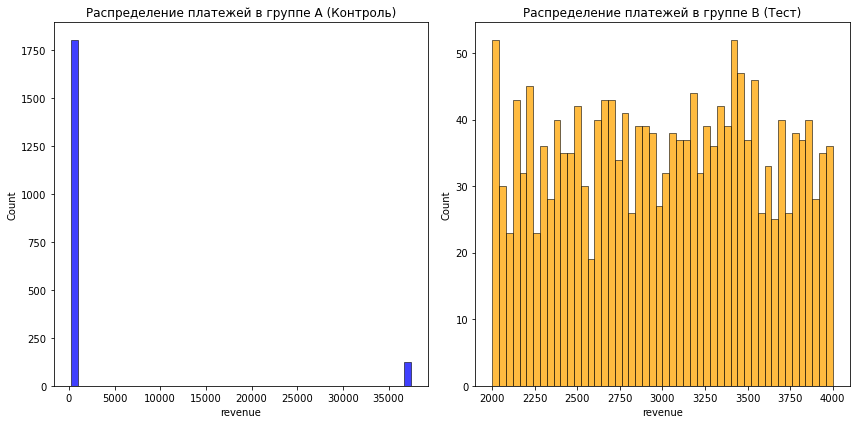

In [36]:
# Строим гистограммы распределения выручки для каждой группы
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=paying_df[paying_df['testgroup'] == 'a'], x='revenue', bins=50, color='blue')
plt.title('Распределение платежей в группе A (Контроль)')

plt.subplot(1, 2, 2)
sns.histplot(data=paying_df[paying_df['testgroup'] == 'b'], x='revenue', bins=50, color='orange')
plt.title('Распределение платежей в группе B (Тест)')

plt.tight_layout()
plt.show()

Видно, что в контрольной группе игроки разделились на два полярных лагеря, те кто дает большие чеки, но таких игроков очень мало, и большое количество игроков, которые делают покупки на очень маленькие чеки. В тестовой группе игроки распределилсь равномерно, их платежи составляют от 2000 до 4000 тысяч рублей. 

Проведем детальный анализ контрольной группы и посмотрим на сколько сильно влияние игроков, которые совершают крупные покупки. Обозначим условие, что крупная покупка > 5000 рублей

In [37]:
# Фильтруем платящих пользователей контрольной группы A
group_a_paying = df[(df['testgroup'] == 'a') & (df['revenue'] > 0)]

In [38]:
# Определяем "крупных плательщиков" (платежи больше 5000)
whales_limit = 5000
whales = group_a_paying[group_a_paying['revenue'] > whales_limit]
regular_payers_a = group_a_paying[group_a_paying['revenue'] <= whales_limit]

In [39]:
regular_payers_a

,user_id,revenue,testgroup
72,73,351,a
341,342,290,a
385,386,250,a
712,713,255,a
1346,1347,230,a
...,...,...,...
404304,404305,360,a
404315,404316,262,a
404543,404544,369,a
404602,404603,251,a


In [40]:
whales

,user_id,revenue,testgroup
416,417,37324,a
4428,4429,37304,a
5777,5778,37315,a
8065,8066,37307,a
8743,8744,37334,a
...,...,...,...
360696,360697,37347,a
378668,378669,37297,a
389341,389342,37298,a
394580,394581,37302,a


Видим, что всего 123 игрока являются крупными плательщиками, в то время как 1805 игроков совершают мелкие платежи. Выведем все в цифрах

In [41]:
whales_count = len(whales)
total_payers_a = len(group_a_paying)
whales_share_pct = (whales_count / total_payers_a) * 100

total_revenue_a = group_a_paying['revenue'].sum()
whales_revenue = whales['revenue'].sum()
whales_rev_share_pct = (whales_revenue / total_revenue_a) * 100

print(f"--- Анализ группы А (Контроль) ---")
print(f"Количество платящих пользователей: {total_payers_a}")
print(f"Из них 'крупные плательщики' (чеки > {whales_limit}): {whales_count} ({whales_share_pct:.2f}% от всех платящих)")
print(f"Общая выручка группы А: {total_revenue_a}")
print(f"Выручка, принесенная 'крупными плательщиками': {whales_revenue} ({whales_rev_share_pct:.2f}% от всей выручки)\n")

print(f"Средний чек обычного платящего в группе А: {regular_payers_a['revenue'].mean():.2f}")
print(f"Средний чек 'крупного плательщика' в группе А: {whales['revenue'].mean():.2f}")

--- Анализ группы А (Контроль) ---
Количество платящих пользователей: 1928
Из них 'крупные плательщики' (чеки > 5000): 123 (6.38% от всех платящих)
Общая выручка группы А: 5136189
Выручка, принесенная 'крупными плательщиками': 4590252 (89.37% от всей выручки)

Средний чек обычного платящего в группе А: 302.46
Средний чек 'крупного плательщика' в группе А: 37319.12


Посмотрим на распределение платежей в тестовой группе, чтобы подтвердить однородность данных

In [42]:
group_b_paying = df[(df['testgroup'] == 'b') & (df['revenue'] > 0)]
print(f"Характеристики платежей в группе B:")
print(f"  - Минимальный платеж: {group_b_paying['revenue'].min()}")
print(f"  - Максимальный платеж: {group_b_paying['revenue'].max()}")
print(f"  - Медианный платеж: {group_b_paying['revenue'].median():.2f}")

Характеристики платежей в группе B:
  - Минимальный платеж: 2000
  - Максимальный платеж: 4000
  - Медианный платеж: 3022.00


Сравним основные показатели группы B с группой A

In [43]:
# Рассчитаем общую конверсию в покупку (CR) для обеих групп
cr_a = (df[(df['testgroup'] == 'a') & (df['revenue'] > 0)]['user_id'].count() / df[df['testgroup'] == 'a']['user_id'].count()) * 100
cr_b = (df[(df['testgroup'] == 'b') & (df['revenue'] > 0)]['user_id'].count() / df[df['testgroup'] == 'b']['user_id'].count()) * 100

# Рассчитаем ARPPU (средний чек платящего) для обеих групп
arppu_a_full = df[(df['testgroup'] == 'a') & (df['revenue'] > 0)]['revenue'].mean()
arppu_b_full = df[(df['testgroup'] == 'b') & (df['revenue'] > 0)]['revenue'].mean()

print(f"--- Сравнение ключевых метрик по группам ---")
print(f"Конверсия в покупку (CR):")
print(f"  - Группа А: {cr_a:.3f}%")
print(f"  - Группа B: {cr_b:.3f}%")
print(f"  - Изменение конверсии в тесте: {(cr_b - cr_a) / cr_a * 100:.2f}%\n")

print(f"Средний чек платящего (ARPPU):")
print(f"  - Группа А (с учетом 'крупных плательщиков'): {arppu_a_full:.2f}")
print(f"  - Группа B: {arppu_b_full:.2f}")
print(f"  - Изменение ARPPU в тесте: {(arppu_b_full - arppu_a_full) / arppu_a_full * 100:.2f}%\n")


--- Сравнение ключевых метрик по группам ---
Конверсия в покупку (CR):
  - Группа А: 0.954%
  - Группа B: 0.891%
  - Изменение конверсии в тесте: -6.64%

Средний чек платящего (ARPPU):
  - Группа А (с учетом 'крупных плательщиков'): 2664.00
  - Группа B: 3003.66
  - Изменение ARPPU в тесте: 12.75%



В результате мы видим, что в тестовой группе CR снизился более чем на 6%, но при этом средний чек на одного платящего клиента вырос более, чем на 12% и согласно условию задачи средний чек на одного клиента в тестовой группе выше на 5%, чем в контрольной.

# Статистическая проверка данных
Теперь выполним статитстическую проверку полученных данных, чтобы убедиться, что полученные различия действительно являются закономерными и статистически значимыми.

## Сравнение конверсии (CR)
Нулевая гипотеза H0: Конверсия в покупку в контрольной и тестовой группе одинакова. Внедрение нового набора акционных предложений не повлияло на конверсию.

Альтернативная гипотеза H1: Конверсия в покупку в контрольной и тестовой группе значимо различается.

Проверим данные гипотезы с помощью метода Хи-квадрат

In [44]:
# 1. Создаем в исходном датасете колонку-признак: совершил ли пользователь покупку
df['is_paying'] = df['revenue'] > 0

# 2. Строим таблицу сопряженности (contingency table)
# По строкам будет группа теста (a/b), по столбцам — факт покупки (True/False)
contingency_table = pd.crosstab(df['testgroup'], df['is_paying'])

print("Таблица сопряженности (фактическое распределение):")
print(contingency_table)
print("-" * 50)

# 3. Применяем критерий Хи-квадрат
# correction=True применяет поправку Йетса на непрерывность (рекомендуется для таблиц 2х2)
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table, correction=True)

print(f"Статистика Хи-квадрат: {chi2_stat:.4f}")
print(f"p-value: {p_val:.6f}")
print(f"Степени свободы: {dof}")

# 4. Интерпретируем результат
alpha = 0.05
if p_val < alpha:
    print(f"\np-value менее уровня значимости {alpha}. Нулевая гипотеза отвергается")
    print("Различия в конверсии (CR) между группами статистически значимы.")
else:
    print(f"\np-value больше или равен уровню значимости {alpha}. Нулевую гипотезу отвергнуть не удалось.")
    print("Различия в конверсии (CR) между группами случайны.")

Таблица сопряженности (фактическое распределение):
is_paying   False  True 
testgroup               
a          200175   1928
b          200862   1805
--------------------------------------------------
Статистика Хи-квадрат: 4.3747
p-value: 0.036476
Степени свободы: 1

p-value менее уровня значимости 0.05. Нулевая гипотеза отвергается
Различия в конверсии (CR) между группами статистически значимы.


## Сравнение среднего чека платящего пользователя

Нулевая гипотеза H0: Средний чек платящего пользователя ARPPU в контрольной и тестовой группах одинаков.

Альтернативная гипотеза H1: Средний чек платящего пользователя ARPPU в контрольной и тестовой группах статистически значимо различается.

**Исправлен комментарий:** Проверим данные с помощью метода Bootstrap, т.к. на графиках распределения платежей мы видим один большой выброс в контрольной группе. Распределения платежей не нормальны и имеют разную структуру. В отличие от других методов, Бутстреп не требует нормальности, строит эмпирическое распределение статистики, корректно учитывает асимметрию и тяжёлые хвосты. BCa корректирует смещение и асимметрию CI.
Обычные тесты здесь не подойдут, т.к. предполагают, что «распределение выборочных средних» похоже на нормальное — это работает, когда данные симметричны или когда выборка очень большая (CLT).

In [67]:
from tqdm import tqdm
import os

os.environ["TQDM_NOTEBOOK"] = "0"

In [68]:
# 1. Фильтруем данные: оставляем только платящих пользователей для расчета ARPPU
paying_a = df[(df['testgroup'] == 'a') & (df['revenue'] > 0)]['revenue']
paying_b = df[(df['testgroup'] == 'b') & (df['revenue'] > 0)]['revenue']



Выполнение Bootstrap для ARPPU: 100%|██████████| 2000/2000 [00:00<00:00, 5228.04it/s]


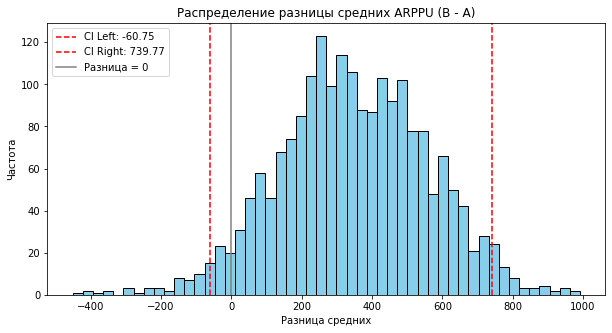

p-value: 0.099307
Доверительный интервал:
                0
0.025  -60.747264
0.975  739.771188


In [69]:
def get_bootstrap_arppu(paying_a, paying_b, boot_it=2000, conf_level=0.95):
    boot_len = max([len(paying_a), len(paying_b)])
    boot_data = [] 
    
    for i in tqdm(range(boot_it), desc="Выполнение Bootstrap для ARPPU"):
        sample_1 = paying_a.sample(boot_len, replace=True).values
        sample_2 = paying_b.sample(boot_len, replace=True).values
        boot_data.append(np.mean(sample_2) - np.mean(sample_1))
        
    pd_boot_data = pd.DataFrame(boot_data)
    
    left_quant = (1 - conf_level) / 2
    right_quant = 1 - (1 - conf_level) / 2
    ci = pd_boot_data.quantile([left_quant, right_quant])
    
    p_1 = stats.norm.cdf(x=0, loc=np.mean(boot_data), scale=np.std(boot_data))
    p_2 = stats.norm.cdf(x=0, loc=-np.mean(boot_data), scale=np.std(boot_data))
    p_value = min(p_1, p_2) * 2
    
    # Построение графика
    plt.figure(figsize=(10, 5))
    plt.hist(pd_boot_data[0], bins=50, color='skyblue', edgecolor='black')
    plt.axvline(x=ci.iloc[0, 0], color='red', linestyle='--', label=f'CI Left: {ci.iloc[0, 0]:.2f}')
    plt.axvline(x=ci.iloc[1, 0], color='red', linestyle='--', label=f'CI Right: {ci.iloc[1, 0]:.2f}')
    plt.axvline(x=0, color='grey', linestyle='-', label='Разница = 0')
    plt.title('Распределение разницы средних ARPPU (B - A)')
    plt.xlabel('Разница средних')
    plt.ylabel('Частота')
    plt.legend()
    plt.show()
    
    return {"boot_data": boot_data, "ci": ci, "p_value": p_value}

# 3. Запускаем бутстрап
boot_results = get_bootstrap_arppu(paying_a, paying_b, boot_it=2000)

print(f"p-value: {boot_results['p_value']:.6f}")
print("Доверительный интервал:")
print(boot_results['ci'])

Сделаем выводы по проведенному выше анализу:
1. p-value: выше уровня значимости 0.05, значит мы принимаем нулевую гипотезу о равенстве средних чеков.
2. Доверительный интервал пересекает 0, что так же говорит о том, что мы не можем отвергать 0 гипотезу
Это значит, что мы не можем утверждать, что средний чек на одного платящего клиента (ARPPU) статистически значимо отличаются между контрольной и тестовой группой 

# Итоговые выводы

## Подведем общие итоги
1. Конверсия в платящего клиента выше в контрольной группе, и разница между CR в контрольной и тестовой группе является статитсически значимой
2. Средний чек на одного игрока (ARPU) и средний чек на одного платящего игрока (ARPPU) выше в тестовой группе. В ходе анализа мы рассмотрели метрику ARPPU и приняли нулевую гипотезу о том, что средний чек на одного платящего игрока между контрольной и тестовой группой не имеют статистически значимой разницы, т.е. примерно одинаковые.
3. Так же, мы увидели, что распределение платежей между платящими игроками контрольной и тестовой группы существенно различаются. В контрольной группе есть большое количество игроков, средний чек которых составляет 302.46 и таких пользователей больше 93%, и около 6% пользователей, которые приносят почти 98% прибыли в контрольной группе **Я считаю, что это особенность модели монетизации, т.к. нет оснований полагать что это ошибки в данных.** В тестовой группе распредление платежей более равномерное и средний чек составляет около 3000 рублей.

## Выводы и рекомендации
Вернемся к вопросу из задания "Какой набор предложений можно считать лучшим?" 
**Ключевой метрикой при реализации данного теста я считаю Конверсию в платящего клиента (CR) и учитывая, что в контрольной группе этот показатель выше и разница между группами является статистически значимой, я бы рекомендовала оставить набор предложений в Контрольной группе.**
Но, необходимо учитывать риски, что основной объем прибыли приносят "крупные плательщики" и потеря таких игроков может существенно сказаться на прибыли компании.
С другой стороны, если учитывать снижение конверсии в платящих пользователей в тестовой группе, то в далекой перспективе это может привести к снижению количества платящих игроков и, в результате, к снижению прибыли.

**Дополнительный комментарий** Конверсия в платящего клиента (CR) выбрана ключевой метрикой не случайно, поясню почему:
1. В задании речь идет о разных акционных предложениях, а акционные предложения направлены на стимулироание первой покупки, увеличение количества платящих клиентов и, возможно, привлечение новой аудитории. Т.е. на увеличение CR. 
2. Учитывая, что в тестовой группе ARPU выше, чем в контрольной, но при этом CR выше в контрольной группе, то выбрав ключевой метрикой ARPU, мы можем не учесть, то, что рост ARPU произошел за счет того, что плательщики в тестовой группе стали тратить больше (более высокий ARPPU), а не потому, что их стало больше. Я предполагаю, что цель проведения А/В теста в данном случае подразумевалась следующая: "Увеличение прибыли за счет увеличения количества платящих клиентов"